# Exercise 4

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import lsqr

## 1. Constructing the Matrix X

The CT reconstruction probelm can be written as a linear system $X \beta=y$. Here, $\beta$ is the flattened tomogram image and $y$ is the flattened sinsogram. The matrix $X$ describes the projection geometry of the CT scanner. Each entry $X_i$ represents how much image pixel $j$ contributes to sensor measurement $i$. The pixel index is defined as $j=j_a + M j_b$, and the sensor response index is defined as $i = i_p + N_p i_o$, where $i_p$ is the sensor bin index and $i_o$ is the projection angle index.

In [2]:
def construct_X(M, alphas, Np=None):
    if Np is None:
        Np = int(np.ceil(np.sqrt(2) * M))
        if Np % 2 == 0:
            Np += 1

    alphas = np.asarray(alphas, dtype=float)

    No = len(alphas)
    D = M * M
    N = No * Np

    # Pixel indices j = ja + M * jb
    j = np.arange(D, dtype=np.int32)
    ja = j % M
    jb = j // M

    # Pixel-center coordinates.
    # a increases from left to right.
    # b increases from bottom to top.
    a = ja.astype(np.float32) - (M - 1) / 2.0
    b = (M - 1) / 2.0 - jb.astype(np.float32)

    sensor_center = (Np - 1) / 2.0

    i_indices = []
    j_indices = []
    weights = []

    for io, alpha in enumerate(alphas):
        theta = np.deg2rad(alpha)

        # Unit vector along the rotated sensor array
        n_a = np.cos(theta)
        n_b = np.sin(theta)

        # Projection of all pixel centers onto the sensor array
        p = n_a * a + n_b * b + sensor_center

        # The ray contributes to the two neighboring sensor bins
        ip_left = np.floor(p).astype(np.int32)
        w_right = p - ip_left
        w_left = 1.0 - w_right

        # Valid left sensor bin
        valid_left = (ip_left >= 0) & (ip_left < Np) & (w_left > 0)

        i_indices.append(ip_left[valid_left] + Np * io)
        j_indices.append(j[valid_left])
        weights.append(w_left[valid_left])

        # Valid right sensor bin
        ip_right = ip_left + 1
        valid_right = (ip_right >= 0) & (ip_right < Np) & (w_right > 0)

        i_indices.append(ip_right[valid_right] + Np * io)
        j_indices.append(j[valid_right])
        weights.append(w_right[valid_right])

    i_indices = np.concatenate(i_indices).astype(np.int32)
    j_indices = np.concatenate(j_indices).astype(np.int32)
    weights = np.concatenate(weights).astype(np.float32)

    X = coo_matrix(
        (weights, (i_indices, j_indices)),
        shape=(N, D),
        dtype=np.float32
    )

    return X

In [3]:
X = construct_X(10, [-33, 1, 42])

X_example = np.load("hs_tomography/X_example.npy")

print("X shape:", X.shape)
print("Number of stored entries:", X.nnz)
print("Maximum absolute difference:", np.max(np.abs(X.toarray() - X_example)))
print("All close:", np.allclose(X.toarray(), X_example))

assert np.allclose(X.toarray(), X_example)

X shape: (45, 100)
Number of stored entries: 600
Maximum absolute difference: 0.0
All close: True


### Visualization

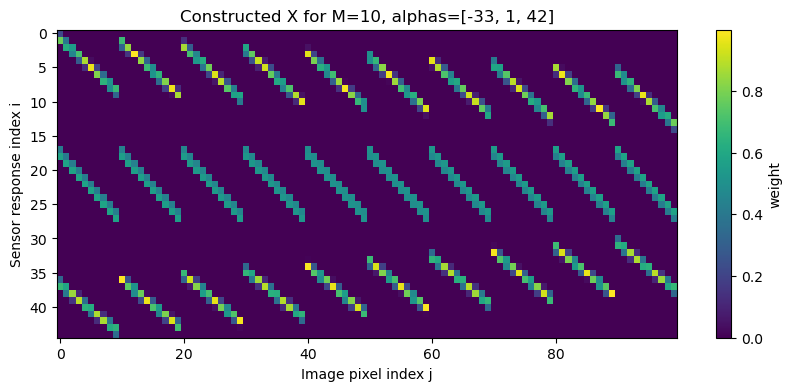

In [4]:
plt.figure(figsize=(10, 4))
plt.imshow(X.toarray(), aspect="auto", interpolation="nearest")
plt.title("Constructed X for M=10, alphas=[-33, 1, 42]")
plt.xlabel("Image pixel index j")
plt.ylabel("Sensor response index i")
plt.colorbar(label="weight")
plt.show()

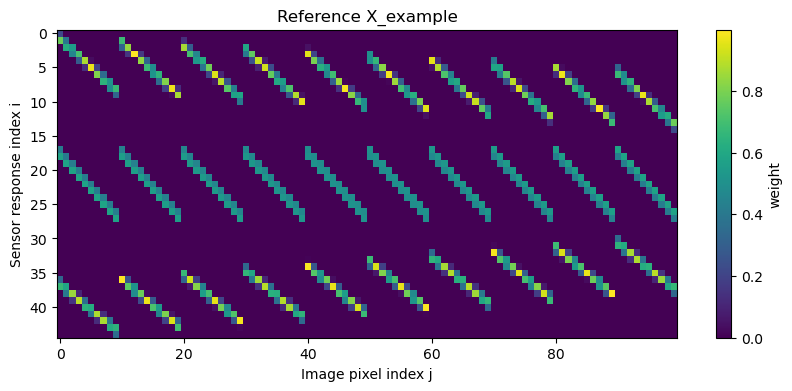

In [5]:
plt.figure(figsize=(10, 4))
plt.imshow(X_example, aspect="auto", interpolation="nearest")
plt.title("Reference X_example")
plt.xlabel("Image pixel index j")
plt.ylabel("Sensor response index i")
plt.colorbar(label="weight")
plt.show()

The constructed matrix for M=10 and angles [-33, 1, 42] was compared with the provided reference matrix `X_example.npy`. The maximum absolute difference was 0.0, and `np.allclose()` returned True. Therefore, the implementation of `construct_X()` matches the expected projection matrix.

The matrix has shape (45, 100) because there are 3 projection angles, 15 sensor bins, and 100 image pixels. It contains 600 stored entries, which is consistent with the fact that each image pixel contributes to at most two sensor bins for each projection angle.

## 2. Recovering the Image
### Load data

In [6]:
# Load small data for debugging
alphas_77 = np.load("hs_tomography/alphas_77.npy")
y_77 = np.load("hs_tomography/y_77.npy")

print("alphas_77 shape:", alphas_77.shape)
print("y_77 shape:", y_77.shape)

# Load large data for final reconstruction
alphas_195 = np.load("hs_tomography/alphas_195.npy")
y_195 = np.load("hs_tomography/y_195.npy")

print("alphas_195 shape:", alphas_195.shape)
print("y_195 shape:", y_195.shape)

alphas_77 shape: (90,)
y_77 shape: (9810,)
alphas_195 shape: (179,)
y_195 shape: (49225,)


### Visualization

In [7]:
def plot_sinogram(y, No, Np, title):
    sinogram = y.reshape(No, Np)

    plt.figure(figsize=(8, 4))
    plt.imshow(sinogram.T, cmap="gray", aspect="auto", interpolation="nearest")
    plt.title(title)
    plt.xlabel("Projection angle index")
    plt.ylabel("Sensor bin index")
    plt.colorbar(label="Measured intensity")
    plt.show()

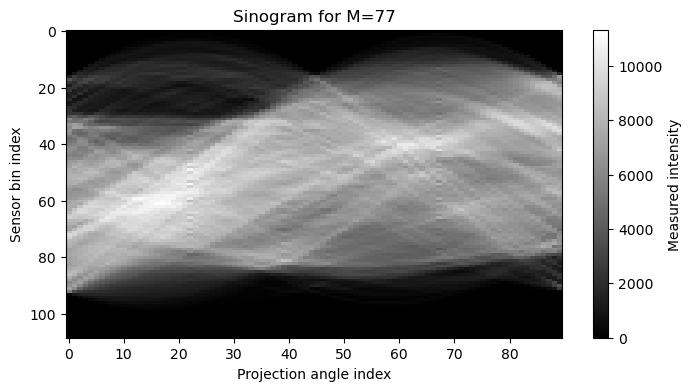

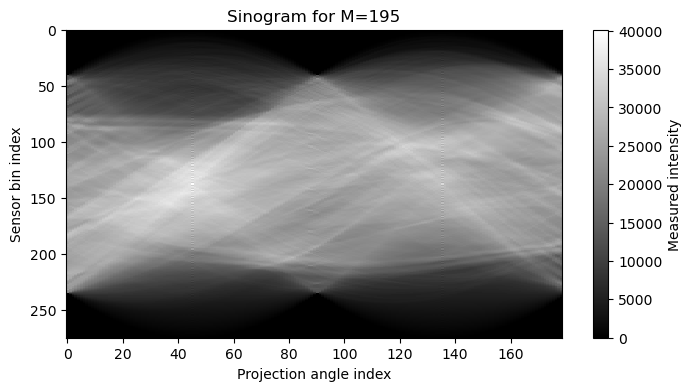

In [8]:
plot_sinogram(y_77, len(alphas_77), 109, "Sinogram for M=77")
plot_sinogram(y_195, len(alphas_195), 275, "Sinogram for M=195")

### Construct X and report sparsity

In [9]:
M_small = 77
Np_small = 109

X_77 = construct_X(M_small, alphas_77, Np_small)

print("X_77 shape:", X_77.shape)
print("Number of non-zero entries:", X_77.nnz)

sparsity_77 = 1 - X_77.nnz / (X_77.shape[0] * X_77.shape[1])
print("Sparsity:", sparsity_77)

X_77 shape: (9810, 5929)
Number of non-zero entries: 1066978
Sparsity: 0.98165553683247


In [10]:
M_large = 195
Np_large = 275

X_195 = construct_X(M_large, alphas_195, Np_large)

print("X_195 shape:", X_195.shape)
print("Number of non-zero entries:", X_195.nnz)

sparsity_195 = 1 - X_195.nnz / (X_195.shape[0] * X_195.shape[1])
print("Sparsity:", sparsity_195)

X_195 shape: (49225, 38025)
Number of non-zero entries: 13535933
Sparsity: 0.9927684191089434


The sparsity matrix for the small dataset has hape (9810, 5929) and contains 1,066,978 non-zero entries. Its sparsity is $1 - \frac{1,066,978}{9810 \cdot 5929} \approx 0.9817$. Thus, about 98.17% of the matrix entries are zero.

The sparse matrix for the large dataset has shape (49225, 38025) and contains 13,535,933 non-zero entries. Its sparsity is $1- \frac{13,535,933}{49225 \cdot 38025} \approx 0.9928$. 

Thus, about 99.28% of the matrix entries are zero. This confirms that a sparse representation is necessary for memory-efficient computation.

### Solve least-squares problem

In [11]:
# Small reconstruction
X_77_csc = X_77.tocsc()

result_77 = lsqr(
    X_77_csc,
    y_77,
    atol=1e-5,
    btol=1e-5
)

beta_77 = result_77[0]

print("LSQR stopping reason:", result_77[1])
print("Number of iterations:", result_77[2])
print("Residual norm:", result_77[3])

LSQR stopping reason: 1
Number of iterations: 274
Residual norm: 62.59722125921405


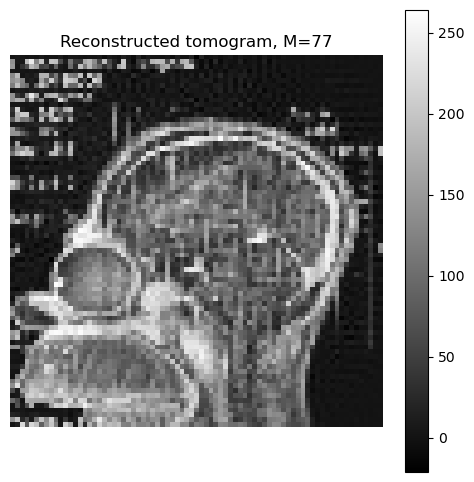

In [12]:
img_77 = beta_77.reshape(M_small, M_small)

plt.figure(figsize=(6, 6))
plt.imshow(img_77, cmap="gray")
plt.title("Reconstructed tomogram, M=77")
plt.axis("off")
plt.colorbar()
plt.show()

In [13]:
# Large reconstruction
X_195_csc = X_195.tocsc()

result_195 = lsqr(
    X_195_csc,
    y_195,
    atol=1e-5,
    btol=1e-5
)

beta_195 = result_195[0]

print("LSQR stopping reason:", result_195[1])
print("Number of iterations:", result_195[2])
print("Residual norm:", result_195[3])

LSQR stopping reason: 1
Number of iterations: 152
Residual norm: 295.2221847038363


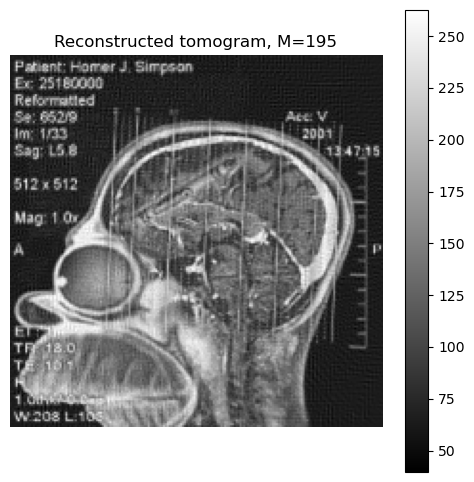

In [14]:
img_195 = beta_195.reshape(M_large, M_large)

plt.figure(figsize=(6, 6))
plt.imshow(img_195, cmap="gray")
plt.title("Reconstructed tomogram, M=195")
plt.axis("off")
plt.colorbar()
plt.show()

### Diagnosis

The least-squares problem $X\beta \approx y$ was solved using `scipy.sparse.linalg.lsqr`. I did not compute the pseudo-inverse explicitly, because this would destroy the sparsity of $X$ and would be inefficient for the large matrix.

The small reconstruction already shows the head structure, which indicates that the projection matrix was constructed correctly. However, the resolution is too low for a reliable diagnosis.

The large reconstruction is much clearer. It shows a dense, crayon-like foreign object inside H.S.'s head. This object is the most likely cause of the headache. A reasonable treatment would be careful surgical removal of the foreign object while avoiding damage to the surrounding brain tissue.

## 3. Minimizing the Radiation Dose